In [37]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [30]:
img_path = "../images/lenna.png"
img = cv.imread(img_path)

cv.imshow("Original Image", img)
cv.waitKey(0)
cv.destroyAllWindows()

### 1.  Write a python program to find the complement of an image as given by the equation

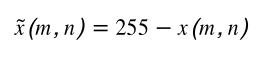


In [31]:
complement_img = 255 - img
cv.imshow("Complement Image", complement_img)

cv.waitKey(0)
cv.destroyAllWindows()

2.  Write a python program to implement gamma correction for an image where where γ values are real numbers and inew is the new intensity value for a pixel .  Check with different values of γ.

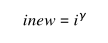

Note : The maximum intensity value is 255.


In [32]:
combined_image = img

for gamma_value in [0.5, 1, 2, 3, 4, 5]:

    normalized_img = img / 255.0
    gamma_corrected_normalized_img = normalized_img ** gamma_value

    rescaled_gamma_corrected_img = (255 * gamma_corrected_normalized_img).astype(np.uint8)
    cv.putText(rescaled_gamma_corrected_img, f"Gamma={gamma_value}", (10,30), 0, 1, 0, 1)

    combined_image = cv.hconcat([combined_image, rescaled_gamma_corrected_img])

cv.imshow("Gamma Correction Comparison", combined_image)
cv.waitKey(0)
cv.destroyAllWindows()

3. Write a python program to display  histogram for a given image.

Using `cv.calcHist()`

```python
cv.calcHist([img], [0], None, [256], [0, 256])
````

* `[img]` → image
* `[0]` → channel 0 = B, 1 = G, 2 = R
* `None` → no mask, use whole image
* `[256]` → 256 intensity levels
* `[0, 256]` → intensity range

Using `plt.hist()`

```python
plt.hist(img.ravel(), bins=256, range=[0, 256])
```

* `img.ravel()` → flatten image
* `bins=256` → intensity levels
* `range=[0, 256]` → intensity range


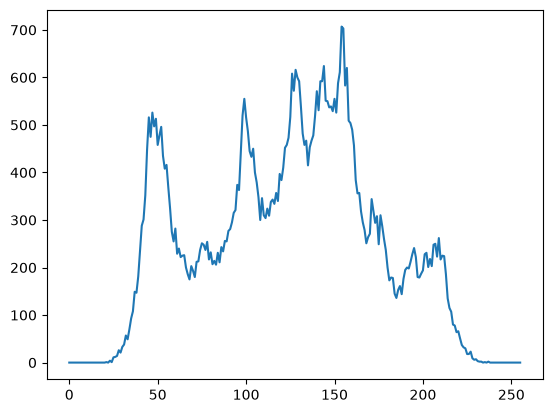

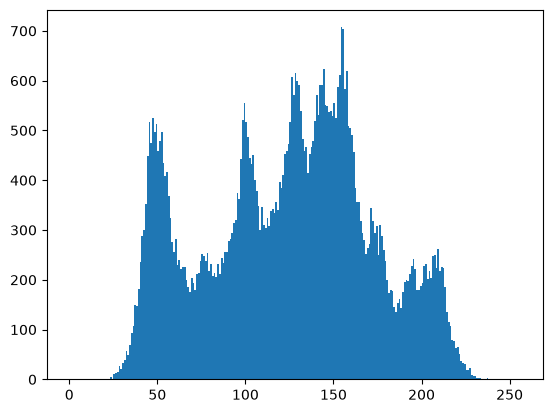

In [33]:
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
hist = cv.calcHist([gray_img], [0], None, [256], [0, 256])

plt.plot(hist)
plt.show()

plt.hist(gray_img.ravel(), bins=256, range=[0, 256])
plt.show()

4. Let i and inew are the gray levels before and after contrast stretching. Use the transformation equation to improve the contrast. Draw the histograms of both the original image and contrast stretched images.

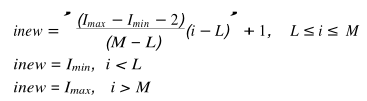

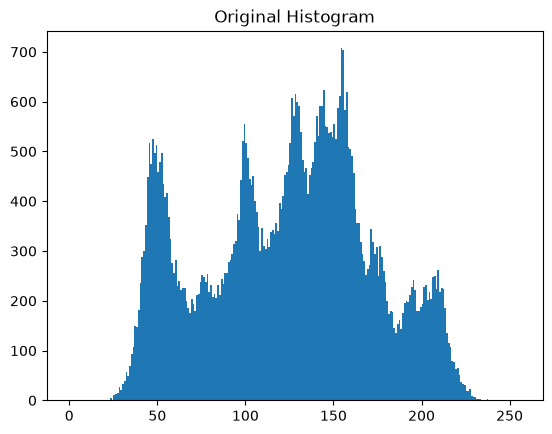

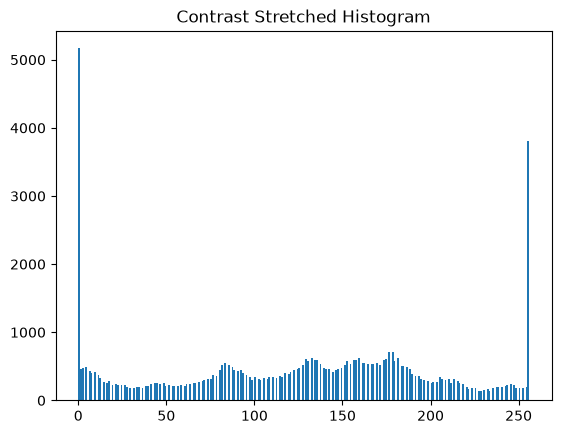

In [34]:
L = 50
M = 200
Imin = 0
Imax = 255

contrast = gray_img.copy()

height, width = gray_img.shape[:2]

for i in range(height):
    for j in range(width):

        if gray_img[i, j] < L:
            contrast[i, j] = Imin

        elif gray_img[i, j] > M:
            contrast[i, j] = Imax

        else:
            contrast[i, j] = ((Imax - Imin - 2) / (M - L)) * (gray_img[i, j] - L) + 1

cv.imshow("Original", gray_img)
cv.imshow("Contrast Stretched", contrast)

plt.hist(gray_img.ravel(), bins=256, range=[0, 256])
plt.title("Original Histogram")
plt.show()

plt.hist(contrast.ravel(), bins=256, range=[0, 256])
plt.title("Contrast Stretched Histogram")
plt.show()

cv.waitKey(0)
cv.destroyAllWindows()

Write a program to implement histogram equalization

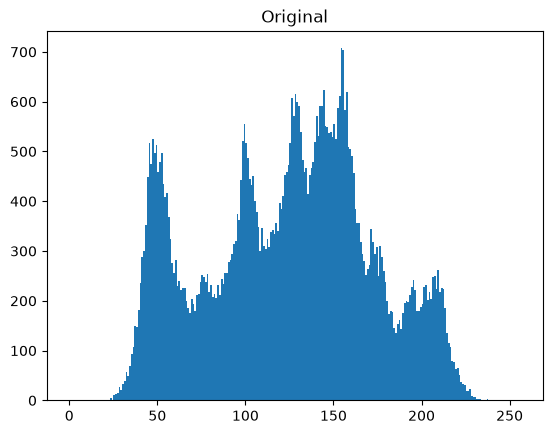

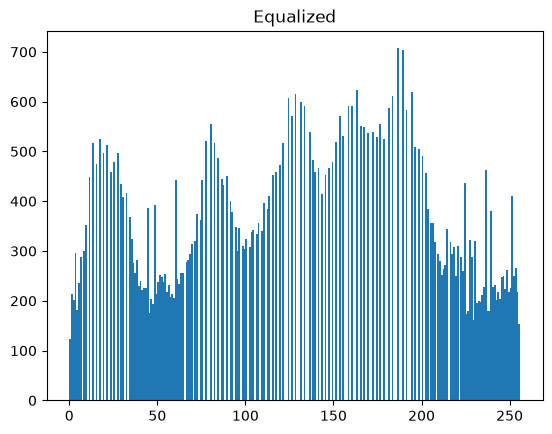

In [35]:
equalized_img = cv.equalizeHist(gray_img)

cv.imshow("Original", gray_img)
cv.imshow("Equalized", equalized_img)

plt.hist(gray_img.ravel(), bins=256, range=[0, 256])
plt.title("Original")
plt.show()

plt.hist(equalized_img.ravel(), bins=256, range=[0, 256])
plt.title("Equalized")
plt.show()

cv.waitKey(0)
cv.destroyAllWindows()

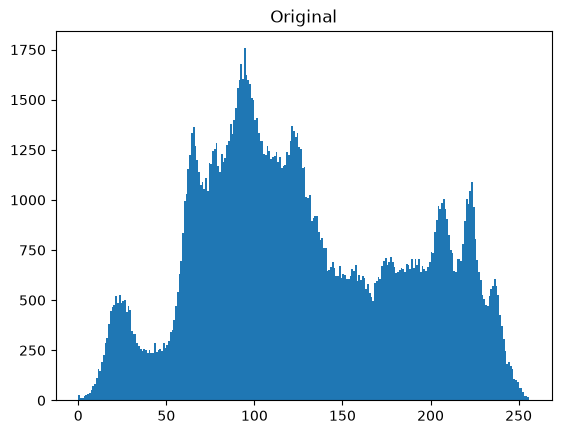

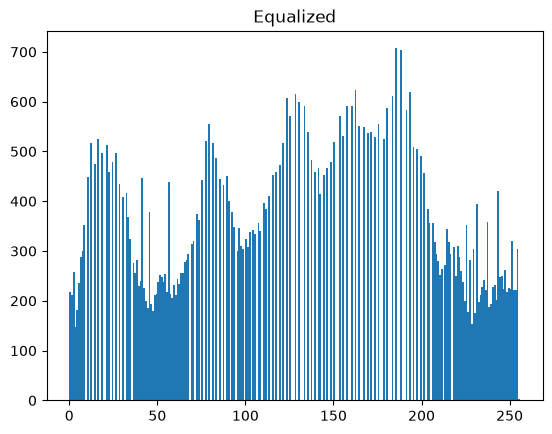

In [36]:
# 1. Histogram
hist, bins = np.histogram(gray_img.flatten(), 256, [0, 256])

# 2. CDF
cdf = hist.cumsum()

# 3. Minimum non-zero CDF
cdf_min = cdf[cdf > 0].min()

# 4. Equalization mapping
equalized = ((cdf - cdf_min) / (cdf.max() - cdf_min) * 255)

# 5. Apply mapping to every pixel
equalized_img = equalized[gray_img].astype(np.uint8)

cv.imshow("Original", gray_img)
cv.imshow("Equalized", equalized_img)

plt.hist(img.ravel(), bins=256, range=[0, 256])
plt.title("Original")
plt.show()

plt.hist(equalized_img.ravel(), bins=256, range=[0, 256])
plt.title("Equalized")
plt.show()

cv.waitKey(0)
cv.destroyAllWindows()

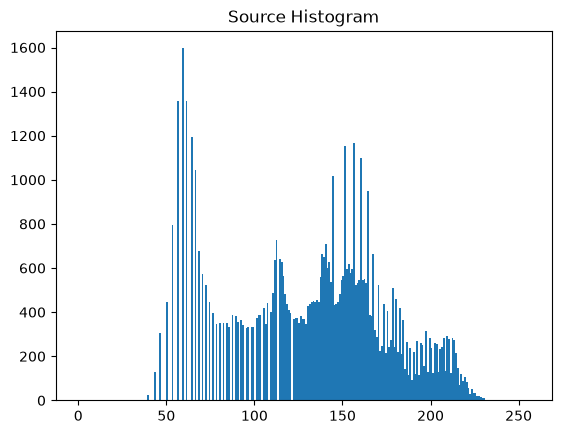

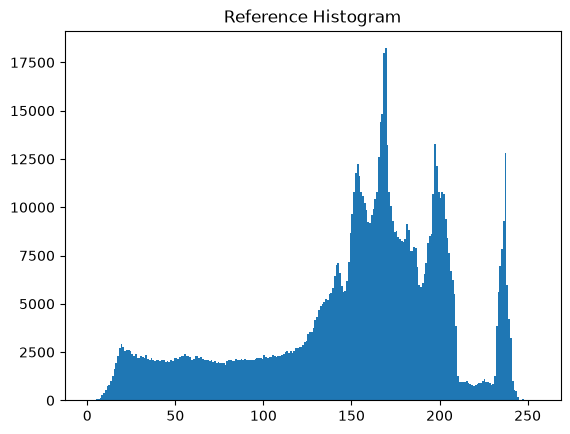

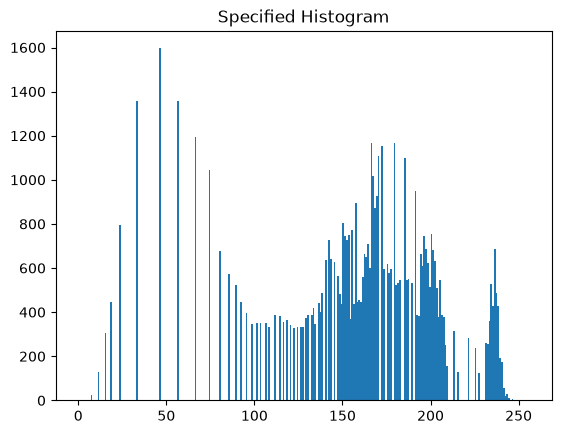

In [38]:
source = cv.imread("../images/lenna.png", 0)
reference = cv.imread("../images/lenna/dup_lenna.png", 0)

# 1. Histograms
source_hist, _ = np.histogram(source.ravel(), 256, [0, 256])
ref_hist, _ = np.histogram(reference.ravel(), 256, [0, 256])

# 2. CDF
source_cdf = source_hist.cumsum()
ref_cdf = ref_hist.cumsum()

# 3. Normalize CDF
source_cdf = source_cdf / source_cdf[-1]
ref_cdf = ref_cdf / ref_cdf[-1]

# 4. Find mapping
mapping = np.zeros(256, dtype=np.uint8)

for i in range(256):
    mapping[i] = np.abs(ref_cdf - source_cdf[i]).argmin()

# 5. Apply mapping
specified = mapping[source]

# Show
cv.imshow("Source", source)
cv.imshow("Reference", reference)
cv.imshow("Specified", specified)

plt.hist(source.ravel(), bins=256, range=[0, 256])
plt.title("Source Histogram")
plt.show()

plt.hist(reference.ravel(), bins=256, range=[0, 256])
plt.title("Reference Histogram")
plt.show()

plt.hist(specified.ravel(), bins=256, range=[0, 256])
plt.title("Specified Histogram")
plt.show()

cv.waitKey(0)
cv.destroyAllWindows()

Write a program to implement threshold operation  :
	To convert a gray-scale image in to a binary image

		If I(r, c)  > T
	    		I(r, c) = 1
		else
	    		I(r, c) = 0.

	where T is the user input.  Try with different values of T and consolidate your analysis. Sample output is given. 

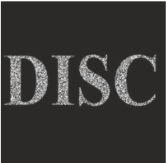

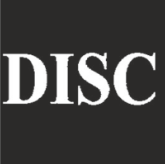

In [43]:
disc_path = "../images/DISC.png"

disc = cv.imread(disc_path, 0)
images = []

for threshold in [50, 100, 150, 200]:

    binary = disc.copy()

    for h in range(height):
        for w in range(width):
            if disc[h, w] > threshold:
                binary[h, w] = 255
            else:
                binary[h, w] = 0

    images.append(binary)

combined = cv.hconcat(images)

cv.imshow("Different Thresholds", combined)
cv.waitKey(0)
cv.destroyAllWindows()